In [ ]:
import numpy as np
import matplotlib.pyplot as plt

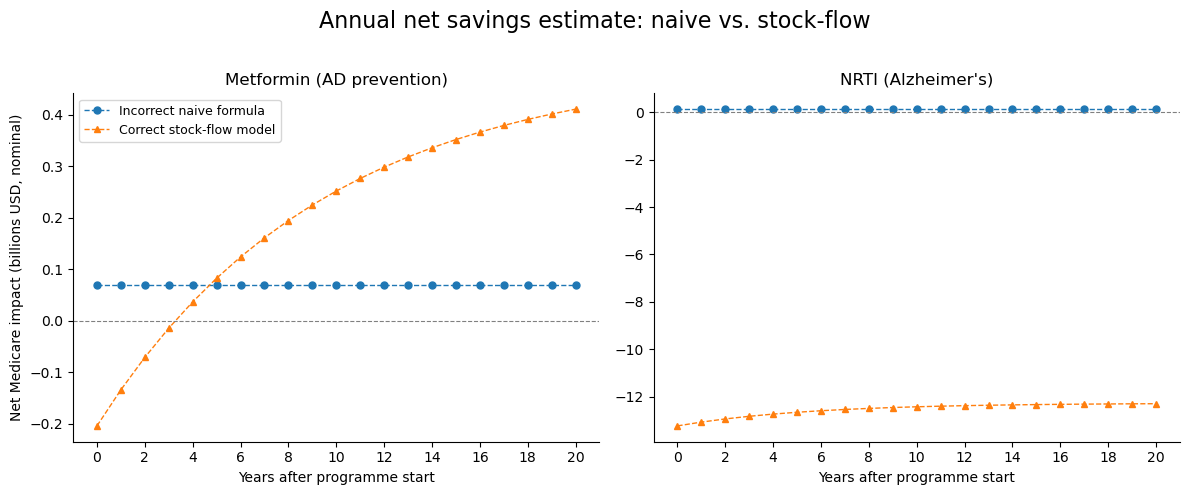

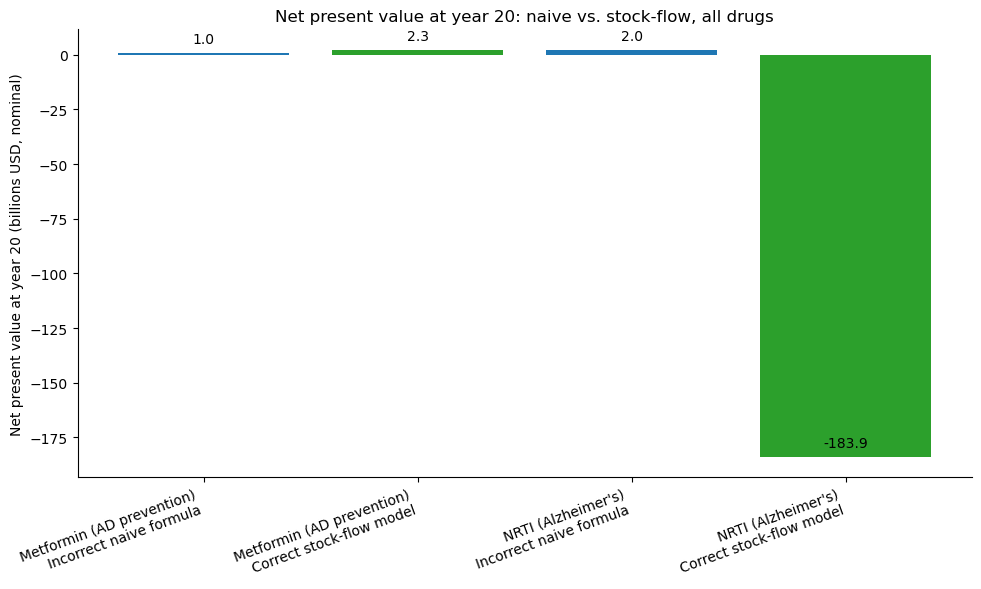

In [18]:
def npv(series, rate, start_year=0):
    """
    Calculate the net present value (NPV) of a series of cash flows, optionally starting from a given year.

    Parameters
    ----------
    series : array-like
        Sequence of cash flows, one per period.
    rate : float
        Discount rate per period (e.g., 0.03 for 3%).
    start_year : int, optional
        The year (index) from which to start the NPV calculation. Default is 0 (start from the beginning).

    Returns
    -------
    float
        Net present value of the series from start_year onward.
    """
    years = np.arange(len(series))
    mask = years >= start_year
    return np.sum(series[mask] / (1 + rate) ** (years[mask] - start_year))

def get_impact_curves(params, years, adoption=0.1):
    """
    Compute naive and stock-flow net impact curves for a drug/indication.

    Parameters
    ----------
    params : dict
        Dictionary with keys: N, i, r, c_AD, c_RX, (optional) A, m.
    years : array-like
        Years to compute over.

    Returns
    -------
    dict
        Dictionary with keys 'naive_wrong', 'naive_right', 'stock_net'.
    """
    N = params['N']
    i = params['i']
    r = params['r']
    c_AD = params['c_AD']
    c_RX = params['c_RX']
    A = adoption
    m = params['m']

    delta_I = N * i * r * A
    annual_drug_cost = N * A * c_RX

    naive_wrong = np.full_like(years, delta_I * (c_AD - c_RX), dtype=float)
    naive_right = np.full_like(years, delta_I * c_AD - N * A * c_RX, dtype=float)
    deltaP_t = (delta_I / m) * (1 - (1 - m) ** years)
    stock_net = deltaP_t * c_AD - annual_drug_cost

    return {
        'naive_wrong': naive_wrong,
        'naive_right': naive_right,
        'stock_net': stock_net
    }

# --- Drug parameter sets ---
years = np.arange(0, 21)  # 0–20

# Define all drugs/indications and their parameters
drug_params = {
    "Metformin (AD prevention)": {
        'N': 30_000_000,
        'i': 0.05,
        'r': 0.13,
        'A': 0.10,
        'c_AD': 3_591,
        'c_RX': 68,
        'm': 1/10
    },
    "NRTI (Alzheimer's)": {
        'N': 62_000_000,
        'i': 0.03,
        'r': 0.06,
        'c_AD': 14_366,
        'c_RX': 2_135,
        'm': 1/6
    }
}

discount_rate = 0.04

# --- Compute curves for each drug ---
impact_curves = {}
for drug, params in drug_params.items():
    impact_curves[drug] = get_impact_curves(params, years)

# --- Plot 1: Three subplots, one per drug ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (drug, curves) in zip(axes, impact_curves.items()):
    ax.plot(
        years, curves['naive_wrong'] / 1e9,
        marker='o', markersize=5, linestyle='--', linewidth=1,
        label="Incorrect naive formula"
    )
    ax.plot(
        years, curves['stock_net'] / 1e9,
        marker='^', markersize=5, linestyle='--', linewidth=1,
        label="Correct stock-flow model"
    )
    ax.axhline(0, linestyle="--", linewidth=0.8, color='gray')
    ax.set_xlabel("Years after programme start")
    ax.set_title(drug)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(years[::2])  # Ensure x axis shows integer years
axes[0].set_ylabel("Net Medicare impact (billions USD, nominal)")
axes[0].legend(loc='upper left', fontsize=9)
fig.suptitle("Annual net savings estimate: naive vs. stock-flow", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# --- Plot 2: NPV bar plot for all drugs and approaches ---
# Optionally, set NPV to start from a certain year (e.g., year 7)
npv_start_year = 0  # Change to 7 for NPV from year 7 onward

labels = []
npvs = []
colors = []
color_map = {
    'naive_wrong': 'tab:blue',
    'stock_net': 'tab:green'
}
approach_names = {
    'naive_wrong': "Incorrect naive formula",
    'stock_net': "Correct stock-flow model"
}
for drug, curves in impact_curves.items():
    for key in ['naive_wrong', 'stock_net']:
        labels.append(f"{drug}\n{approach_names[key]}")
        npvs.append(npv(curves[key], discount_rate, start_year=npv_start_year) / 1e9)
        colors.append(color_map[key])

fig2, ax2 = plt.subplots(figsize=(10, 6))
bars = ax2.bar(labels, npvs, color=colors)
ax2.set_ylabel("Net present value at year 20 (billions USD, nominal)")
if npv_start_year == 0:
    ax2.set_title("Net present value at year 20: naive vs. stock-flow, all drugs")
else:
    ax2.set_title(f"Net present value from year {npv_start_year} to 20: naive vs. stock-flow, all drugs")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
for bar in bars:
    height = bar.get_height()
    ax2.annotate(f"{height:.1f}",
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 5),  # 5 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()

In [24]:
temp = 225_000 * 0.1 * 0.3 * (0.57 * 0.34 * 18_350 - 68)
f'{temp / 1e6:.1f}'

'23.5'